# 04 - EDA: Universal Metadata (WLASL + MS-ASL)

Explores `merged_datasets/universal_metadata_has_video_wlasl_msasl_merged.csv`:
1. Frame count and duration distribution
2. FPS distribution
3. Samples per class
4. Signer vs label relationship
5. Video dimensions
6. Numeric correlations

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
CSV_PATH = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video_wlasl_msasl_merged.csv'

print('CSV_PATH:', CSV_PATH)
print('Exists:', CSV_PATH.exists())

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.head()

CSV_PATH: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_has_video_wlasl_msasl_merged.csv
Exists: True
Shape: (28796, 12)


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_CBQXPn152YI...,3523,3609.0,87.0,3.440,25.00,msasl_172,True,640.0,360.0
1,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_R_ES8RZua1g...,675,734.0,60.0,1.967,30.00,msasl_40,True,568.0,320.0
2,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_VcRx3U-HpTE...,8111,8197.0,87.0,3.583,24.00,msasl_125,True,1280.0,720.0
3,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,4840,4881.0,42.0,1.368,29.97,msasl_26,True,1280.0,720.0
4,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,5514,5545.0,32.0,1.034,29.97,msasl_26,True,1280.0,720.0


## 2. Frame Count and Duration Distribution

In [3]:
length_stats = df['length_frames'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
duration_stats = df['duration_sec'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
frame_start_stats = df['start_frame'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print('length_frames stats:')
display(length_stats.to_frame('length_frames'))
print('duration_sec stats:')
display(duration_stats.to_frame('duration_sec'))
print('start_frame stats:')
display(frame_start_stats.to_frame('start_frame'))

length_frames stats:


,length_frames
count,28796.000000
mean,81.232428
std,36.144203
min,9.000000
10%,39.000000
25%,55.000000
50%,76.000000
75%,99.000000
90%,132.000000
95%,151.000000


duration_sec stats:


,duration_sec
count,28796.000000
mean,2.851720
std,1.282751
min,0.267000
10%,1.376000
25%,1.968000
50%,2.670000
75%,3.437000
90%,4.638000
95%,5.311250


start_frame stats:


,start_frame
count,28796.000000
mean,2803.880053
std,5656.254380
min,0.000000
10%,0.000000
25%,1.000000
50%,1.000000
75%,3095.000000
90%,9114.000000
95%,14541.000000


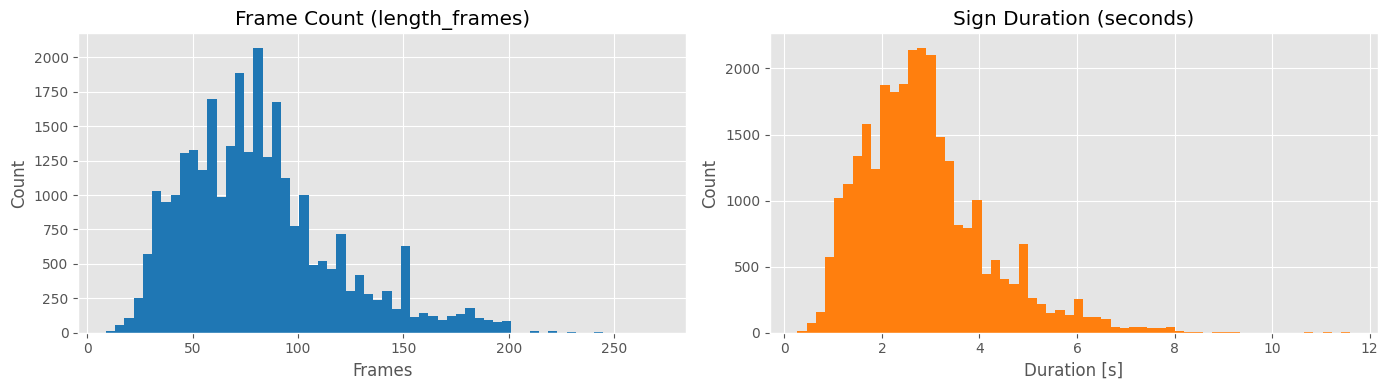

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['length_frames'].dropna().hist(bins=60, ax=axes[0], color='#1f77b4')
axes[0].set_title('Frame Count (length_frames)')
axes[0].set_xlabel('Frames')
axes[0].set_ylabel('Count')

df['duration_sec'].dropna().hist(bins=60, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Sign Duration (seconds)')
axes[1].set_xlabel('Duration [s]')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. FPS Distribution

In [5]:
fps_stats = df['fps'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
display(fps_stats.to_frame('fps'))

fps_counts = df['fps'].round(3).value_counts().sort_index()
print('Most common FPS values:')
display(fps_counts.sort_values(ascending=False).head(15).to_frame('count'))

,fps
count,28796.000000
mean,28.460427
std,3.088723
min,7.430000
10%,23.976189
25%,25.000000
50%,29.970000
75%,29.970030
90%,30.000000
95%,30.296090


Most common FPS values:


,count
fps,
29.970,13876
25.000,3973
30.000,2847
23.976,2323
15.000,385
24.000,326
29.997,265
30.003,265
29.996,234


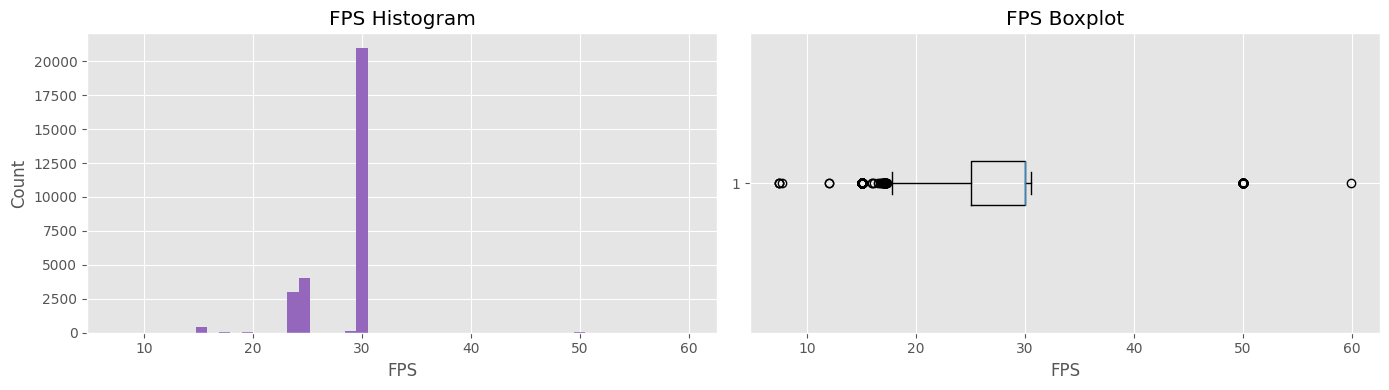

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['fps'].dropna().hist(bins=50, ax=axes[0], color='#9467bd')
axes[0].set_title('FPS Histogram')
axes[0].set_xlabel('FPS')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['fps'].dropna(), vert=False)
axes[1].set_title('FPS Boxplot')
axes[1].set_xlabel('FPS')

plt.tight_layout()
plt.show()

## 4. Samples per Class

In [7]:
label_counts = df['label'].value_counts()
print('Unique classes:', df['label'].nunique())
print('Mean samples/class:', round(label_counts.mean(), 2))
print('Median samples/class:', round(label_counts.median(), 2))
print('Min/Max samples/class:', int(label_counts.min()), '/', int(label_counts.max()))

display(label_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('samples_per_label'))
display(label_counts.head(20).to_frame('count').rename_axis('label'))

Unique classes: 2054
Mean samples/class: 14.02
Median samples/class: 8.0
Min/Max samples/class: 1 / 67


,samples_per_label
count,2054.000000
mean,14.019474
std,11.994503
min,1.000000
10%,4.000000
25%,5.000000
50%,8.000000
75%,20.000000
90%,31.000000
95%,40.000000


,count
label,
eat,67
nice,62
need,62
teacher,61
bird,61
mother,60
spring,59
orange,58
finish,57


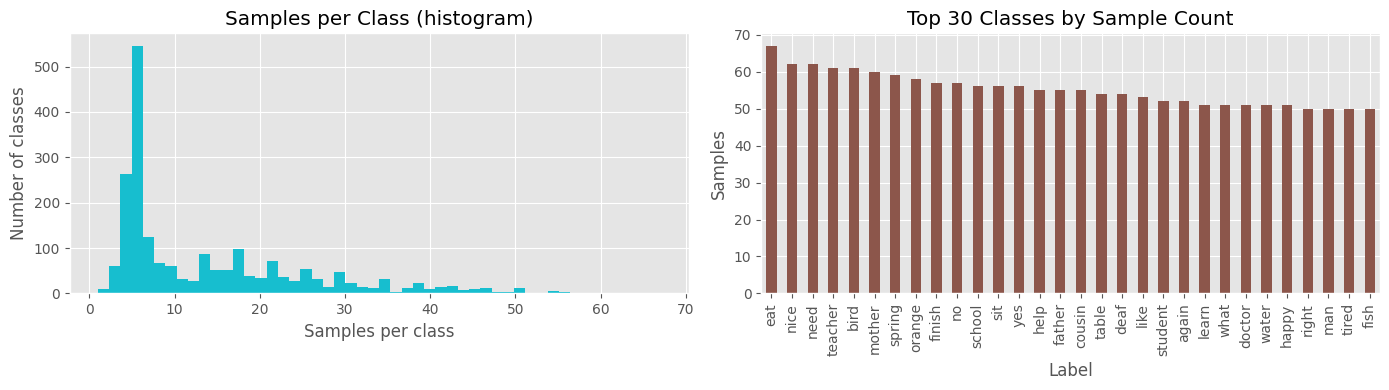

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

label_counts.hist(bins=50, ax=axes[0], color='#17becf')
axes[0].set_title('Samples per Class (histogram)')
axes[0].set_xlabel('Samples per class')
axes[0].set_ylabel('Number of classes')

label_counts.sort_values(ascending=False).head(30).plot(kind='bar', ax=axes[1], color='#8c564b')
axes[1].set_title('Top 30 Classes by Sample Count')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Samples')

plt.tight_layout()
plt.show()

## 5. Signer vs Label

In [9]:
signer_counts = df['signer_id'].value_counts(dropna=False)
labels_per_signer = df.groupby('signer_id')['label'].nunique().sort_values(ascending=False)

print('Unique signers:', df['signer_id'].nunique())
print('Mean samples/signer:', round(signer_counts.mean(), 2))
print('Mean unique labels/signer:', round(labels_per_signer.mean(), 2))

display(signer_counts.head(20).to_frame('samples').rename_axis('signer_id'))
display(labels_per_signer.head(20).to_frame('unique_labels').rename_axis('signer_id'))

Unique signers: 227
Mean samples/signer: 126.85
Mean unique labels/signer: 95.59


,samples
signer_id,
wlasl_11,1983
msasl_12,1553
msasl_0,1480
wlasl_12,1380
msasl_26,1373
msasl_124,973
wlasl_13,966
msasl_32,769
wlasl_4,723


,unique_labels
signer_id,
wlasl_11,1436
wlasl_12,1260
wlasl_13,909
msasl_0,802
msasl_26,759
msasl_12,640
wlasl_2,546
msasl_124,534
wlasl_4,528


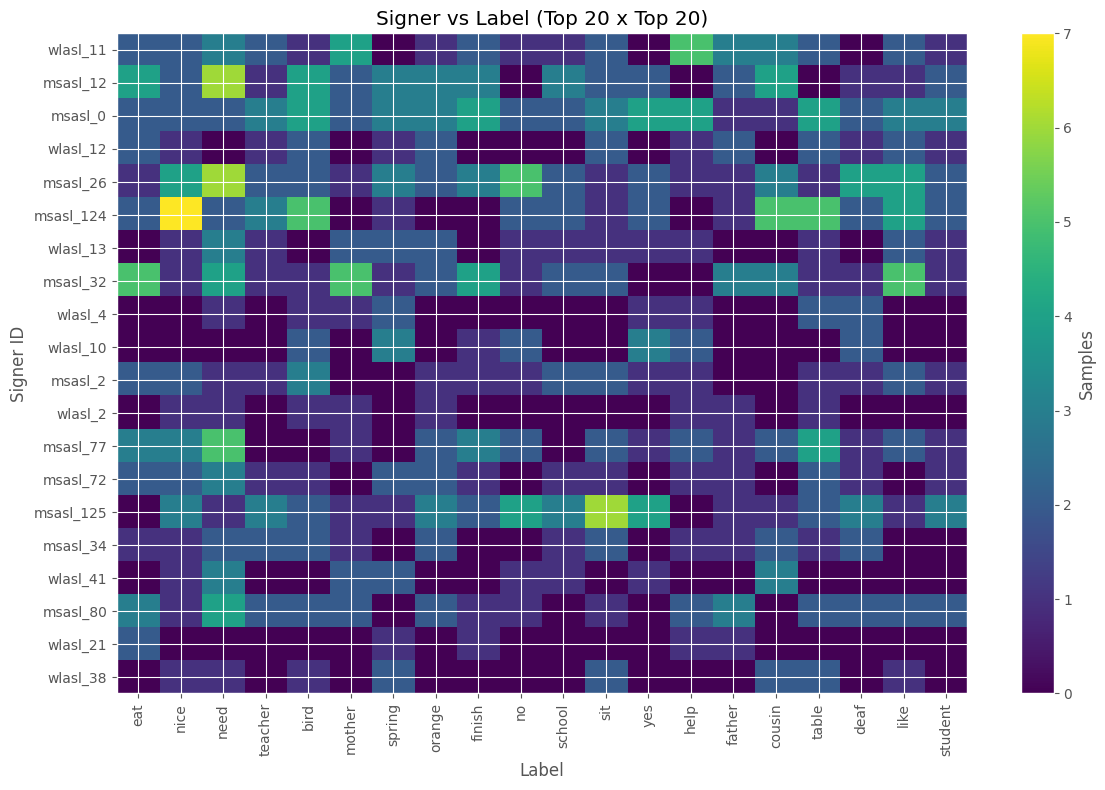

In [10]:
top_signers = signer_counts.head(20).index
top_labels = label_counts.head(20).index

heat = pd.crosstab(df['signer_id'], df['label']).reindex(index=top_signers, columns=top_labels, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat.values, aspect='auto')
ax.set_title('Signer vs Label (Top 20 x Top 20)')
ax.set_xlabel('Label')
ax.set_ylabel('Signer ID')
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=90)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
fig.colorbar(im, ax=ax, label='Samples')
plt.tight_layout()
plt.show()

In [11]:
contingency = pd.crosstab(df['signer_id'], df['label'])
chi2, p_value, dof, _ = chi2_contingency(contingency)
n = contingency.values.sum()
r, k = contingency.shape
cramers_v = np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1))

print(f'Chi2: {chi2:.2f}')
print(f'p-value: {p_value:.6e}')
print(f"Cramer's V: {cramers_v:.4f}")

if cramers_v < 0.1:
    print('Interpretation: very weak association')
elif cramers_v < 0.3:
    print('Interpretation: weak/moderate association')
elif cramers_v < 0.5:
    print('Interpretation: moderate/strong association')
else:
    print('Interpretation: strong association')

Chi2: 478701.76
p-value: 5.409625e-52
Cramer's V: 0.2712
Interpretation: weak/moderate association


## 6. Video Dimensions

In [12]:
size_df = df[['video_width', 'video_height']].dropna()
print('Samples with known dimensions:', len(size_df))
display(size_df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

top_res = df.dropna(subset=['video_width', 'video_height']).assign(res=lambda x: x['video_width'].astype(int).astype(str) + 'x' + x['video_height'].astype(int).astype(str))['res'].value_counts().head(15)
print('Most common resolutions:')
display(top_res.to_frame('count'))

Samples with known dimensions: 28796


,video_width,video_height
count,28796.000000,28796.000000
mean,764.565287,457.971385
std,429.747539,227.127938
min,202.000000,180.000000
10%,288.000000,240.000000
25%,480.000000,360.000000
50%,640.000000,360.000000
75%,854.000000,540.000000
90%,1280.000000,720.000000
95%,1920.000000,1080.000000


Most common resolutions:


,count
res,
640x360,7279
1280x720,5272
480x360,2886
288x192,2668
720x400,1875
320x240,1845
640x480,1824
1920x1080,1768
656x370,1045


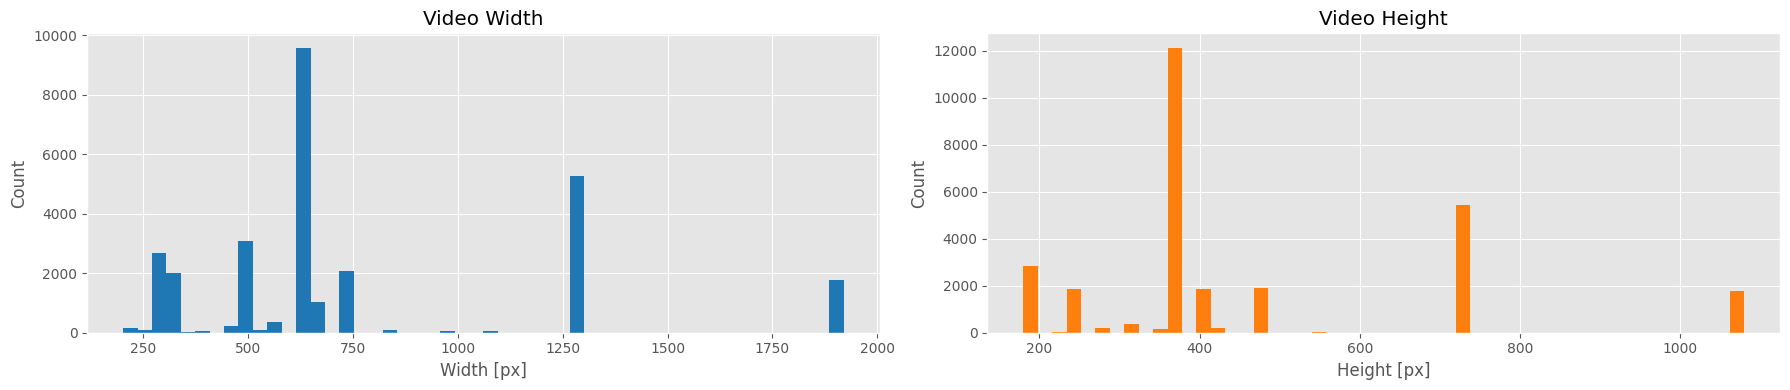

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

df['video_width'].dropna().hist(bins=50, ax=axes[0], color='#1f77b4')
axes[0].set_title('Video Width')
axes[0].set_xlabel('Width [px]')
axes[0].set_ylabel('Count')

df['video_height'].dropna().hist(bins=50, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Video Height')
axes[1].set_xlabel('Height [px]')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

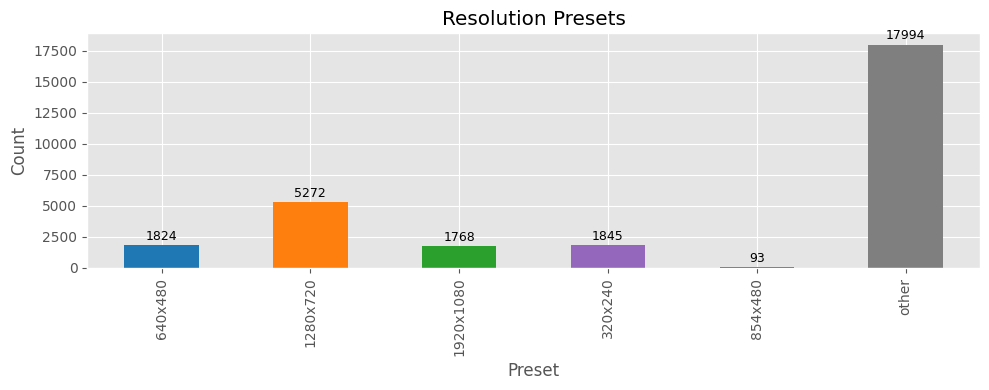

Top 15 resolutions:


,count
resolution,
640x360,7279
1280x720,5272
480x360,2886
288x192,2668
720x400,1875
320x240,1845
640x480,1824
1920x1080,1768
656x370,1045


In [14]:
res_df = df.dropna(subset=['video_width', 'video_height']).copy()
res_df = res_df[(res_df['video_width'] > 0) & (res_df['video_height'] > 0)]
res_df['resolution'] = res_df['video_width'].astype(int).astype(str) + 'x' + res_df['video_height'].astype(int).astype(str)

preset_order = ['640x480', '1280x720', '1920x1080', '320x240', '854x480']
preset_counts = res_df['resolution'].value_counts()

preset_plot = pd.Series({preset: int(preset_counts.get(preset, 0)) for preset in preset_order})
other_count = int(len(res_df) - preset_plot.sum())
preset_plot['other'] = other_count

fig, ax = plt.subplots(figsize=(10, 4))
preset_plot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#7f7f7f'])
ax.set_title('Resolution Presets')
ax.set_xlabel('Preset')
ax.set_ylabel('Count')

for i, val in enumerate(preset_plot.values):
    ax.text(i, val + max(1, 0.01 * max(preset_plot.values)), str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Top 15 resolutions:')
display(preset_counts.head(15).to_frame('count'))

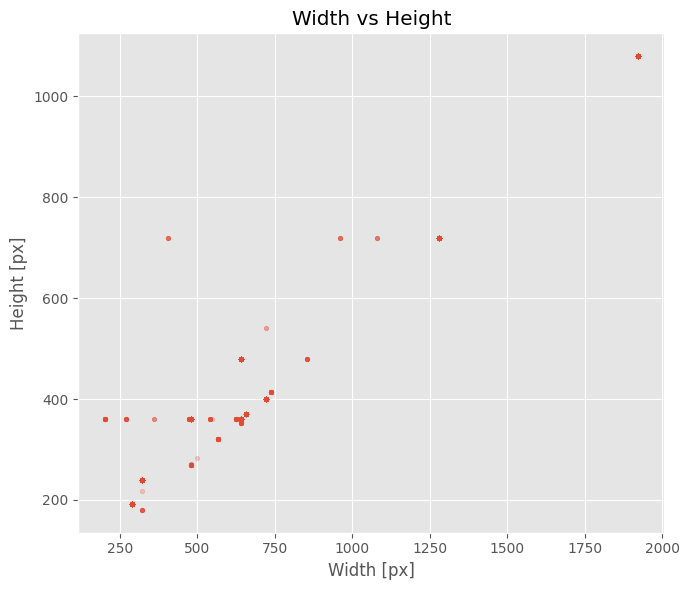

In [15]:
sample_scatter = df.dropna(subset=['video_width', 'video_height']).sample(min(3000, df.dropna(subset=['video_width', 'video_height']).shape[0]), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample_scatter['video_width'], sample_scatter['video_height'], alpha=0.25, s=10)
ax.set_title('Width vs Height')
ax.set_xlabel('Width [px]')
ax.set_ylabel('Height [px]')
plt.tight_layout()
plt.show()

## 7. Numeric Correlations

In [16]:
num_cols = ['start_frame', 'end_frame', 'length_frames', 'fps', 'video_width', 'video_height', 'duration_sec']
num_df = df[num_cols].copy()

pearson_corr = num_df.corr(method='pearson')
spearman_corr = num_df.corr(method='spearman')

print('Pearson correlation matrix:')
display(pearson_corr.round(3))
print('Spearman correlation matrix:')
display(spearman_corr.round(3))

Pearson correlation matrix:


,start_frame,end_frame,length_frames,fps,video_width,video_height,duration_sec
start_frame,1.000,1.000,0.185,-0.032,-0.038,-0.047,0.187
end_frame,1.000,1.000,0.191,-0.031,-0.039,-0.048,0.193
length_frames,0.185,0.191,1.000,0.135,-0.162,-0.160,0.959
fps,-0.032,-0.031,0.135,1.000,-0.072,-0.090,-0.120
video_width,-0.038,-0.039,-0.162,-0.072,1.000,0.979,-0.164
video_height,-0.047,-0.048,-0.160,-0.090,0.979,1.000,-0.158
duration_sec,0.187,0.193,0.959,-0.120,-0.164,-0.158,1.000


Spearman correlation matrix:


,start_frame,end_frame,length_frames,fps,video_width,video_height,duration_sec
start_frame,1.000,0.857,0.158,-0.070,0.100,0.063,0.126
end_frame,0.857,1.000,0.468,-0.006,0.065,0.029,0.428
length_frames,0.158,0.468,1.000,0.146,-0.042,-0.035,0.958
fps,-0.070,-0.006,0.146,1.000,0.095,0.121,-0.056
video_width,0.100,0.065,-0.042,0.095,1.000,0.923,-0.068
video_height,0.063,0.029,-0.035,0.121,0.923,1.000,-0.051
duration_sec,0.126,0.428,0.958,-0.056,-0.068,-0.051,1.000


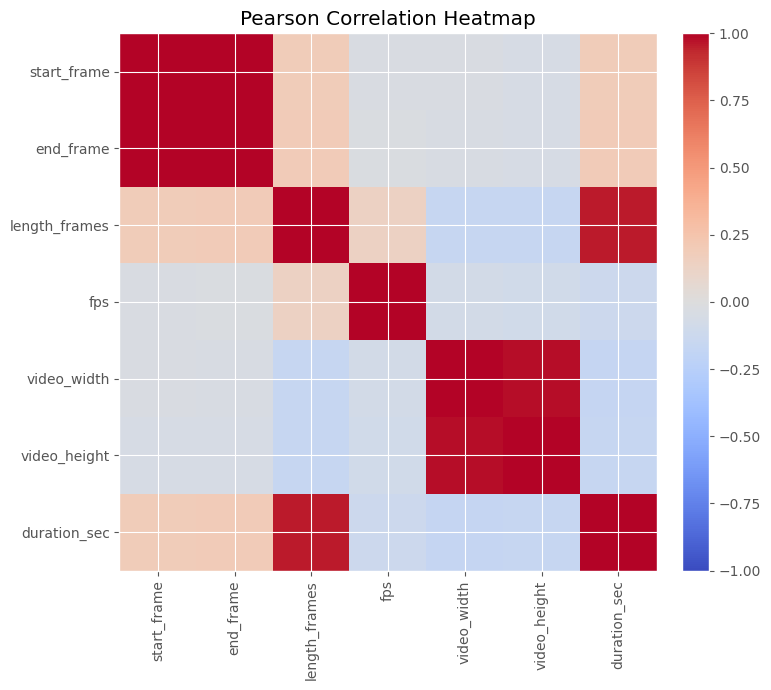

In [17]:
corr = pearson_corr.fillna(0).values
labels = pearson_corr.columns.tolist()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)
ax.set_title('Pearson Correlation Heatmap')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

,samples
source,
msasl,16816
signingsavvy,2668
signschool,1968
aslsearch,1875
asldeafined,1833
spreadthesign,1584
aslsignbank,1050
startasl,623
aslbrick,218


has_video,True
source,
aslbrick,100.0
asldeafined,100.0
aslsearch,100.0
aslsignbank,100.0
elementalasl,100.0
msasl,100.0
signingsavvy,100.0
signschool,100.0
spreadthesign,100.0


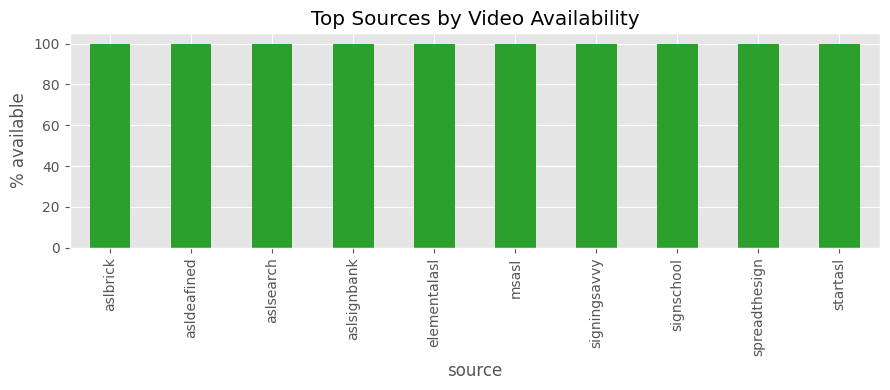

In [18]:
source_avail = pd.crosstab(df['source'], df['has_video'], normalize='index') * 100
source_counts = df['source'].value_counts()

display(source_counts.to_frame('samples'))
display(source_avail.round(2))

if True in source_avail.columns:
    top_have = source_avail[True].sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(9, 4))
    top_have.plot(kind='bar', ax=ax, color='#2ca02c')
    ax.set_title('Top Sources by Video Availability')
    ax.set_ylabel('% available')
    ax.set_xlabel('source')
    plt.tight_layout()
    plt.show()

## 8. Label vs Sign Duration

In [19]:
base_df = df_existing.copy() if 'df_existing' in globals() else df[df['has_video'] == True].copy()
label_duration_df = base_df.dropna(subset=['label', 'duration_sec']).copy()
label_length_df = base_df.dropna(subset=['label', 'length_frames']).copy()

label_duration_stats = label_duration_df.groupby('label').agg(
    samples=('duration_sec', 'size'),
    mean_duration=('duration_sec', 'mean'),
    median_duration=('duration_sec', 'median'),
    std_duration=('duration_sec', 'std'),
    q25_duration=('duration_sec', lambda s: s.quantile(0.25)),
    q75_duration=('duration_sec', lambda s: s.quantile(0.75)),
).sort_values('samples', ascending=False)

label_length_stats = label_length_df.groupby('label').agg(
    samples=('length_frames', 'size'),
    mean_frames=('length_frames', 'mean'),
    median_frames=('length_frames', 'median'),
    std_frames=('length_frames', 'std'),
).sort_values('samples', ascending=False)

print('has_video=True rows only')
print('Top 20 classes: duration stats [seconds]')
display(label_duration_stats.head(20).round(3))

print('Top 20 classes: duration stats [frames]')
display(label_length_stats.head(20).round(2))

min_samples = 10
duration_corr_df = label_duration_stats[label_duration_stats['samples'] >= min_samples].copy()

if len(duration_corr_df) >= 3:
    rho, p_val = spearmanr(duration_corr_df['samples'], duration_corr_df['median_duration'])
    print(f'Spearman(samples, median_duration) for classes with >= {min_samples} samples: rho={rho:.4f}, p-value={p_val:.4e}')
else:
    print('Too few classes after filtering for Spearman correlation.')

has_video=True rows only
Top 20 classes: duration stats [seconds]


,samples,mean_duration,median_duration,std_duration,q25_duration,q75_duration
label,,,,,,
eat,67,3.033,2.670,1.479,2.002,3.808
nice,62,2.938,2.822,1.418,1.952,3.576
need,62,3.154,2.800,1.483,2.035,3.992
teacher,61,3.048,2.703,1.503,2.080,3.670
bird,61,2.851,2.800,1.106,2.102,3.200
mother,60,2.676,2.484,1.327,1.643,3.200
spring,59,3.097,2.870,1.363,2.184,3.538
orange,58,3.131,3.003,1.541,2.043,3.796
finish,57,2.636,2.369,1.312,1.769,3.250


Top 20 classes: duration stats [frames]


,samples,mean_frames,median_frames,std_frames
label,,,,
eat,67,87.45,81.0,40.16
nice,62,83.34,80.5,37.17
need,62,89.85,79.5,40.75
teacher,61,87.00,78.0,36.62
bird,61,81.69,79.0,33.49
mother,60,78.62,71.0,39.69
spring,59,89.75,81.0,36.37
orange,58,88.19,87.0,41.99
finish,57,76.53,70.0,39.23


Spearman(samples, median_duration) for classes with >= 10 samples: rho=-0.0246, p-value=4.4788e-01


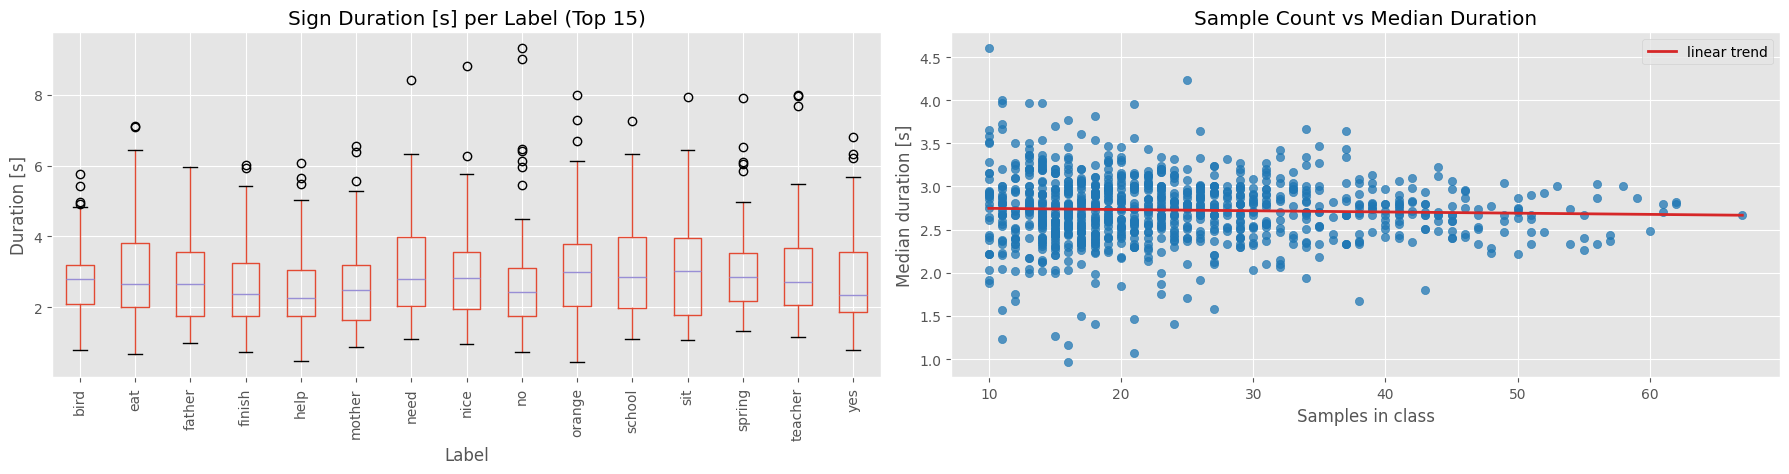

In [20]:
top_labels_by_samples = label_duration_stats.head(15).index
plot_df = label_duration_df[label_duration_df['label'].isin(top_labels_by_samples)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_df.boxplot(column='duration_sec', by='label', ax=axes[0], rot=90)
axes[0].set_title('Sign Duration [s] per Label (Top 15)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Duration [s]')

axes[1].scatter(
    duration_corr_df['samples'],
    duration_corr_df['median_duration'],
    alpha=0.75,
    s=35,
    color='#1f77b4'
)
axes[1].set_title('Sample Count vs Median Duration')
axes[1].set_xlabel('Samples in class')
axes[1].set_ylabel('Median duration [s]')

if len(duration_corr_df) >= 2:
    m, b = np.polyfit(duration_corr_df['samples'], duration_corr_df['median_duration'], 1)
    x = np.linspace(duration_corr_df['samples'].min(), duration_corr_df['samples'].max(), 100)
    axes[1].plot(x, m * x + b, color='#d62728', linewidth=2, label='linear trend')
    axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()